 # **Project Name**    - Flipkart Customer Support CSAT Score Prediction



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Name**            - Anveiksha Sharma



# **Project Summary -**

Flipkart is one of the major e-commerce companies in India that receives millions of customer support interactions every day. The interaction quality determines whether the customer keeps using Flipkart, or moves to one of their many competitors when the customers inquire about issues with returns, refunds, or order problems.

The project consists of an actual Flipkart customer support dataset with 85,907 support tickets. These tickets contain details about the issue category, the contact channel the ticket came through, the agent handling the ticket, the shift and experience level of the agent, and the CSAT score of the interaction. CSAT stands for Customer Satisfaction Score. The score ranges from 1, to 5, which is a score for very unhappy and very happy customers, respectively.

This project aims to develop a model to predict CSAT score, based on information such as response time, agent experience, issue category, and contact channel. This problem falls under the classification problem because we are trying to predict the class that the customer will score (1 through 5) in their CSAT score.

Before building models, the data had to be cleaned: any blank columns removed, dates properly formatted and response time was created as a feature. The data was highly imbalanced with 47,683 entries having CSAT=5 and only 1,056 having CSAT=2 so SMOTE was applied to balance the training data.

Three machine learning models were tested: Logistic Regression yielded 54% accuracy, Decision Tree gave 67.54%, and Random Forest gave 80% accuracy. Random Forest was selected as the final model as it better models non linear relationships and imbalanced data than Logistic Regression and Decision Trees.

The final Random Forest model was pickled. It can be implemented on Flipkart's side to determine which tickets are likely to generate an unhappy customer so it could be addressed more promptly and efficiently before the customer grows too unhappy with the service.

# **GitHub Link -**

https://github.com/anveiksha-max/Flipkart-EDA-Project

# **Problem Statement**


Every day, Flipkart's support team receives thousands of tickets, and the level of satisfaction varies greatly from agent to agent, and from category to category. Some customers finish their interaction, and leave satisfied, while other customers leave with a high level of dissatisfaction after a similar experience.

The business problem is that currently Flipkart has no means to forecast which support tickets would likely lead to dissatisfied customers before an interaction is complete. If they were able to predict this in real-time, they would be able to prioritize those tickets, send the interaction to the agent with most experience, and intervene before the customer is dissatisfied enough to report a low CSAT.

The objective of this machine learning project is to create a classification model to predict the CSAT score of a customer after a support interaction. The model is trained on features such as response time, experience of the agent, category of the issue, contact channel and shift.

A successful model would enable Flipkart to transform from reactive to proactive support, solving potential issues before the customers can even complain.

#### **Define Your Business Objective?**

This project's main business goal is to develop a machine learning model that accurately predicts customer satisfaction (CSAT) scores for Flipkart support.

Predicting CSAT scores in real-time allows Flipkart to identify high-risk tickets that are likely to have low scores, so they can take proactive measures such as assigning agents with more expertise, speeding up response times, or quicker escalation of complex issues.

The target variable in this project is CSAT Score which ranges from 1-5 (5 classes). The aim of the model development process is to achieve high prediction accuracy across all classes with special focus on minority classes such as score 2 and score 3.

The end result is a deployable model saved in a pickle file that can be integrated with Flipkart's support systems to make real-time predictions and enable better decision-making regarding ticket management.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [71]:
try:
    df = pd.read_csv('/content/Customer_support_data.csv')
    print(df.shape)
    df.head()
except FileNotFoundError:
    print("Error: The file 'Customer_support_data.csv' was not found at '/content/Customer_support_data.csv'.")
    print("Please ensure the file is uploaded to your Colab environment or the path is correct.")

(85907, 20)


### Dataset First View

In [72]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [73]:
print("number of rows  :",df.shape[0])
print("Number of columns:",df.shape[1])

number of rows  : 85907
Number of columns: 20


### Dataset Information

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [75]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#### Missing Values/Null Values

In [76]:
print(df.isnull().sum())

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


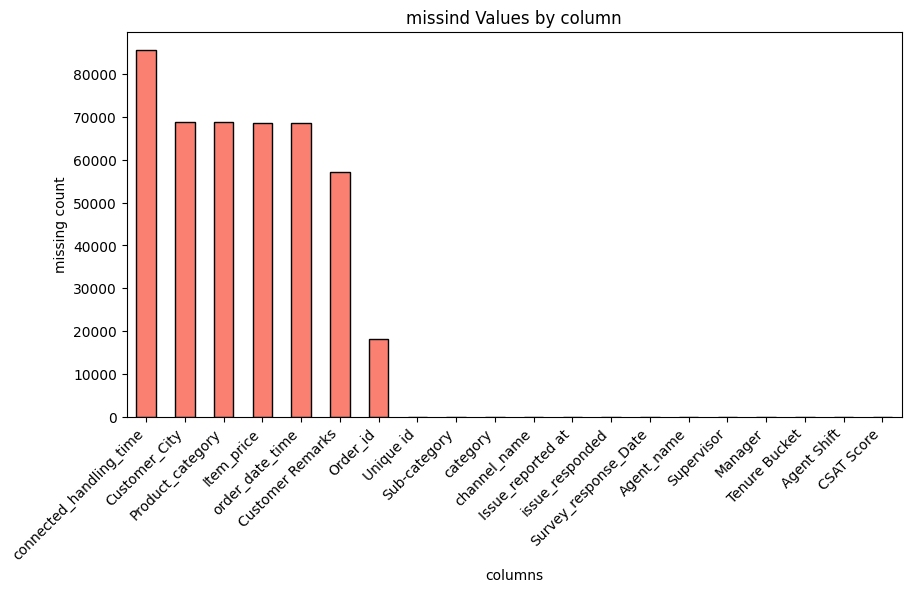

In [77]:
plt.figure(figsize=(10,5))
df.isnull().sum().sort_values(ascending=False).plot(kind='bar',color='salmon',edgecolor='black')
plt.title('missind Values by column')
plt.xlabel('columns')
plt.ylabel('missing count')
plt.xticks(rotation=45,ha='right')
plt.show()

### What did you know about your dataset?

Rows and Columns:This dataset has 85907
rows and 20 columns.Each one of the row is one customer support ticket raised by a customer using flipkart.
Missing values: The connected_handling_time had 85665 missing values so I dropped the column.Customer_City,Product_category,Item_price and order_date_time had 80% missing values so I kept them but didnt rely on them heavily.Customer remarks had 66% missing values which is normal as customers dont usually leave a review.
Target variable:The most important column in this dataset is CSAT Score.It goes from 1 to 5 where 1 means the customer was very unhappy and 5 means they were very happy. This is what we are trying to understand throughout the entire analysis.
Main categories and channels:
Customers contacted support through three channels — Inbound calls, Outcall and Email. Inbound was the most common with around 68,000 tickets. The most common issue category was Returns with over 44,000 tickets, followed by Order Related issues. Together these two categories made up almost 78% of all tickets in the dataset.

## ***2. Understanding Your Variables***

In [78]:
print("all columns in the dataset:")
for i,col in enumerate (df.columns,1):
  print(f"  {i}.{col}")

all columns in the dataset:
  1.Unique id
  2.channel_name
  3.category
  4.Sub-category
  5.Customer Remarks
  6.Order_id
  7.order_date_time
  8.Issue_reported at
  9.issue_responded
  10.Survey_response_Date
  11.Customer_City
  12.Product_category
  13.Item_price
  14.connected_handling_time
  15.Agent_name
  16.Supervisor
  17.Manager
  18.Tenure Bucket
  19.Agent Shift
  20.CSAT Score


In [79]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

There are 20 columns in the data set. The column description is as follows:

Unique id - Unique id for the ticket. There are no other columns with these unique ids. It does not hold any analytical value.

Channel_name - This denotes the channel through which the customer has contacted the support. There are 3 types of channels; Inbound for incoming calls, Outcall for the calls made by the agent and email for email support.

Category - This denotes the primary category of the ticket such as returns, order related, refund related, cancellation, etc.

Sub-category - This is the sub-category of the main category such as, "Reverse Pickup Enquiry", "Replacement Request" etc.

Customer Remarks - This is a free-form text left by the customer, after the interaction with the agent. About 66 percent of the customers didn't leave any remarks.

Order_id - Order id of the order which has to be serviced.

Orderdatetime - Date and time when the order was placed by the customer.

Issue_reported at - Date and time when the customer raised the ticket with the support.

Issue_responded - Date and time when the agent replied to the customer for the first time.

SurveyresponseDate - Date when the customer submitted the satisfaction survey.

Customer_City - City of the customer. 80% of the column data is missing.

Product_category - Category of the product, for example electronics, mobile, furniture, etc. 80% of the column data is missing.

Item_price - Price of the product. 80% of the column data is missing.

Connectedhandlingtime - This column was removed as 99.7% of the data was missing, so it wasn't very usable.

Agent_name - Name of the support agent that was handling the ticket.

Supervisor - Supervisor of the support agent.

Manager - Manager of the supervisor of the support agent.

Tenure Bucket - Tenure (experience in days) of the support agent. The values are On Job Training, 0-30 days, 31-60 days, 61-90 days and more than 90 days.

Agent Shift - Shift of the agent which is Morning, Afternoon, Evening, Night and Split.

CSAT Score - Target variable which stands for Customer Satisfaction Score, which is given by the customer after the interaction and is in the range of 1-5, where 1 stands for very unhappy and 5 stands for very happy.

### Check Unique Values for each variable.

In [80]:
for col in df.columns:
  print(f"{col}:{df[col].nunique()} unique values")

Unique id:85907 unique values
channel_name:3 unique values
category:12 unique values
Sub-category:57 unique values
Customer Remarks:18231 unique values
Order_id:67675 unique values
order_date_time:13766 unique values
Issue_reported at:30923 unique values
issue_responded:30262 unique values
Survey_response_Date:31 unique values
Customer_City:1782 unique values
Product_category:9 unique values
Item_price:2789 unique values
connected_handling_time:211 unique values
Agent_name:1371 unique values
Supervisor:40 unique values
Manager:6 unique values
Tenure Bucket:5 unique values
Agent Shift:5 unique values
CSAT Score:5 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [81]:
#drop useless column
df.drop(columns=['connected_handling_time'],inplace=True)
print("Dropped connected_handling_time")
#convert data columns to datetime
df['Issue_reported at']=pd.to_datetime(df['Issue_reported at'],dayfirst=True)
df['issue_responded']=pd.to_datetime(df['issue_responded'],dayfirst=True)
print("Data columns converted")
#creating resoponse time
df['Response_Time_mins'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60
df.loc[df['Response_Time_mins'] < 0, 'Response_Time_mins'] = None
print("Response_Time_mins created")

# Step 4 - Extract hour and day
df['Issue_Hour'] = df['Issue_reported at'].dt.hour
df['Issue_Day'] = df['Issue_reported at'].dt.day_name()
print("Issue_Hour and Issue_Day extracted")

# Step 5 - Create Satisfaction label
df['Satisfaction'] = df['CSAT Score'].apply(lambda x: 'Happy' if x >= 4 else 'Unhappy')
print("Satisfaction column created")

print("\nFinal shape:", df.shape)


Dropped connected_handling_time
Data columns converted
Response_Time_mins created
Issue_Hour and Issue_Day extracted
Satisfaction column created

Final shape: (85907, 23)


### What all manipulations have you done and insights you found?

Dropped connected_handling_time because 99.7% was empty
Converted date columns so we could calculate time differences
Created Response_Time_mins by subtracting the two date columns
Replaced negative response times with None since they were data errors
Extracted hour and day from the timestamp for time based analysis
Created Satisfaction column to easily separate happy and unhappy customers

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

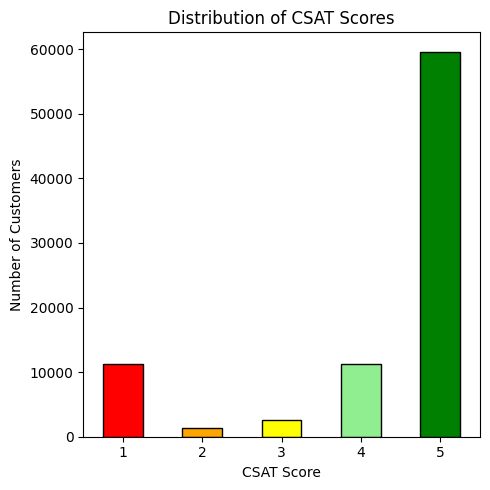

In [82]:
# Chart - 1 CSAT Score DIstribution
plt.figure(figsize=(5, 5))

df['CSAT Score'].value_counts().sort_index().plot(kind='bar',
    color=['red', 'orange', 'yellow', 'lightgreen', 'green'],
    edgecolor='black')

plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart because CSAT Score only has 5 possible values and a bar chart is the simplest way to compare counts across a small number of categories.

##### 2. What is/are the insight(s) found from the chart?

Score 5 is the most common with nearly 60,000 customers giving a perfect rating. Score 2 is the rarest. Score 1 is surprisingly the second highest which shows a clear divide between very happy and very unhappy customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — knowing that 69% of customers give score 5 tells Flipkart their support is working well overall. Negative — the large number of score 1 ratings means thousands of customers are having terrible experiences which could lead to them never shopping on Flipkart again.

#### Chart - 2

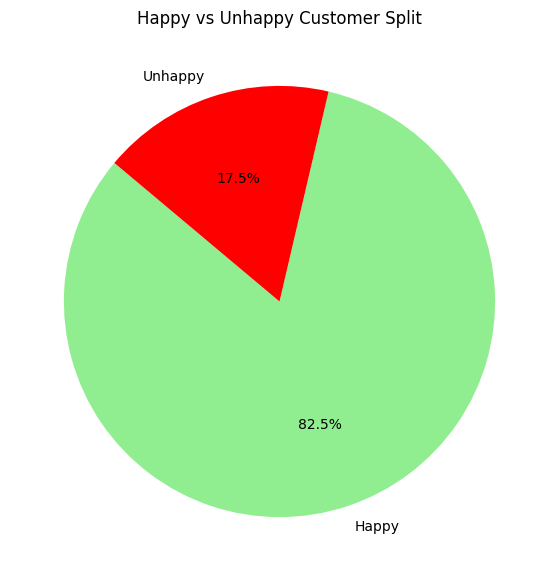

In [83]:
# Chart - 2 Happy vs Unhappy Customer split
plt.figure(figsize=(7, 7))

df['Satisfaction'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'red'], startangle=140)

plt.title('Happy vs Unhappy Customer Split')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a pie chart because it is the best way to show a simple
two way split between two groups. It immediately shows the proportion
of happy versus unhappy customers in a single glance.

##### 2. What is/are the insight(s) found from the chart?

82.5 percent of customers are happy meaning they gave a CSAT score
of 4 or 5. The remaining 17.5 percent are unhappy meaning they gave
a score of 1, 2 or 3. This means roughly 1 in every 6 customers
leaves a support interaction feeling dissatisfied.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that the majority of customers are satisfied with
the support they receive. Negative impact is that at Flipkart's scale
17.5 percent unhappy customers means tens of thousands of bad
experiences every month which directly affects customer retention
and brand reputation.

#### Chart - 3

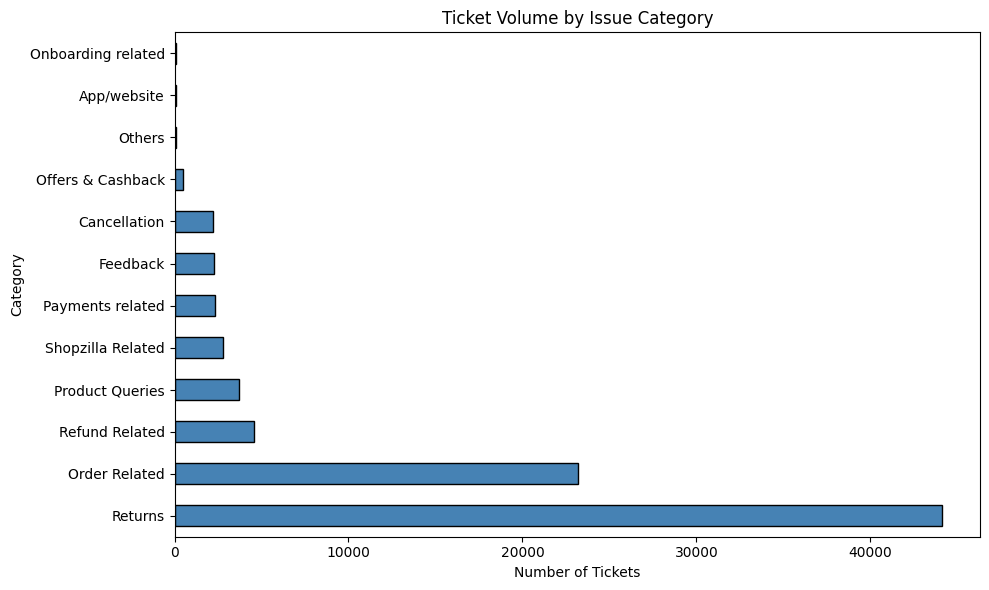

In [84]:
# Chart - 3 Ticket Volume by Issue Category
plt.figure(figsize=(10, 6))

df['category'].value_counts().plot(kind='barh', color='steelblue', edgecolor='black')

plt.title('Ticket Volume by Issue Category')
plt.xlabel('Number of Tickets')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a horizontal bar chart because the category names are long
and a horizontal layout makes them easier to read. It also makes
ranking the categories from most to least tickets very clear.

##### 2. What is/are the insight(s) found from the chart?

Returns is by far the most common issue category with over 44000
tickets. Order Related issues come second with around 23000 tickets.
Together these two categories make up almost 78 percent of all
support tickets in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that knowing which categories dominate helps
Flipkart allocate their resources and agents more effectively.
Negative impact is that the overwhelming volume of return tickets
suggests the return process itself is confusing or broken which
is generating unnecessary support load that could be reduced.

#### Chart - 4

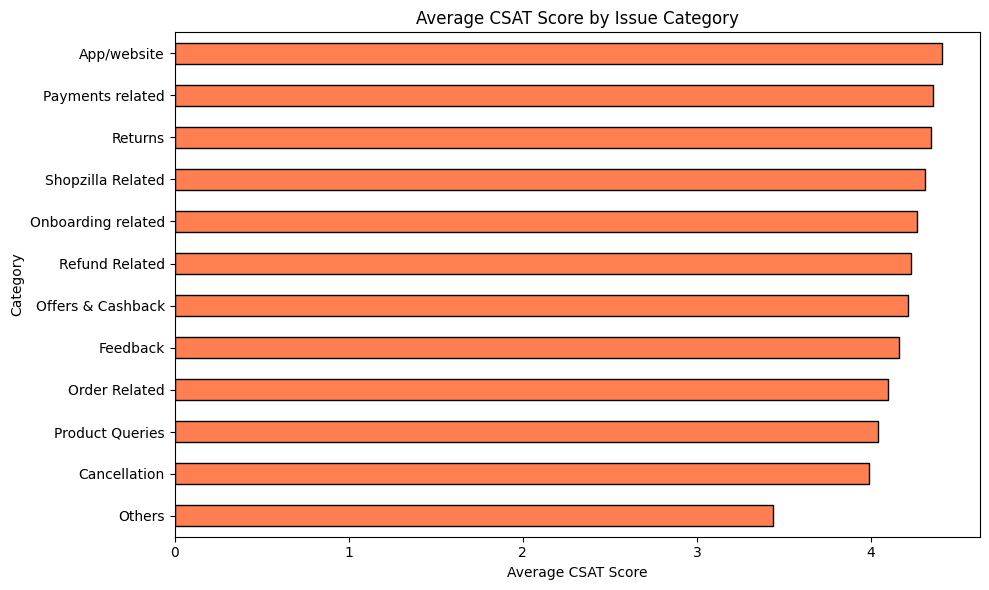

In [85]:
# Chart - 4 Average CSAT Score by Issue Category
plt.figure(figsize=(10, 6))

df.groupby('category')['CSAT Score'].mean().sort_values().plot(kind='barh', color='coral', edgecolor='black')

plt.title('Average CSAT Score by Issue Category')
plt.xlabel('Average CSAT Score')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a sorted horizontal bar chart because it makes it easy
to compare average satisfaction scores across different categories
and immediately spot which ones are performing below average.

##### 2. What is/are the insight(s) found from the chart?

The Others category has the lowest average CSAT score. Offers and
Cashback related issues also score below the overall average. Most
categories cluster around an average score of 4.2 to 4.4.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that most categories have decent satisfaction
scores meaning agents handle the majority of issues reasonably well.
Negative impact is that vague categories like Others having low
scores suggests agents do not have clear guidelines for unusual
issues which leads to poor resolutions and unhappy customers.

#### Chart - 5

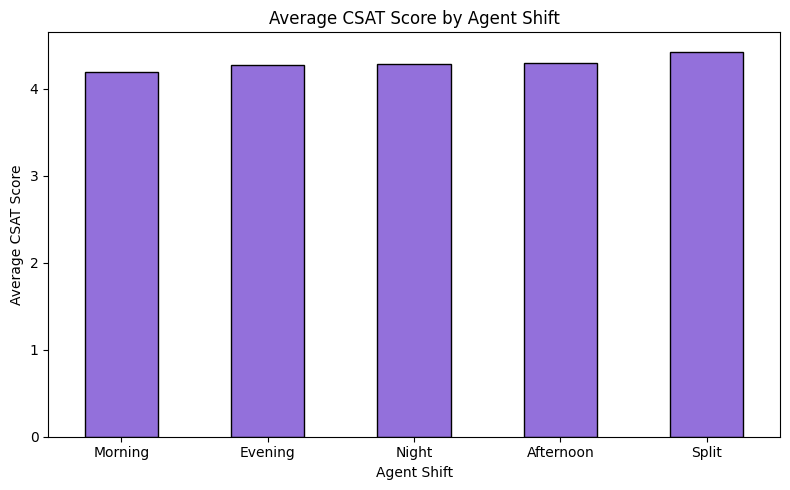

In [86]:
# Chart - 5 Average CSAT Score by Agent shift
plt.figure(figsize=(8, 5))

df.groupby('Agent Shift')['CSAT Score'].mean().sort_values().plot(kind='bar', color='mediumpurple', edgecolor='black')

plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart because it is the clearest way to compare
a single numerical value like average CSAT across a small number
of categories like shifts.

##### 2. What is/are the insight(s) found from the chart?

Split shift has the highest average CSAT score and Morning shift
has the lowest. This is a surprising finding because Morning is
the busiest shift so agents may be more rushed and under more
pressure which could affect their performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that Split shift agents performing well suggests
that flexible scheduling may improve agent performance and customer
satisfaction. Negative impact is that Morning shift underperforming
is concerning since it handles the most tickets and any quality
drop there affects the largest number of customers.

#### Chart - 6

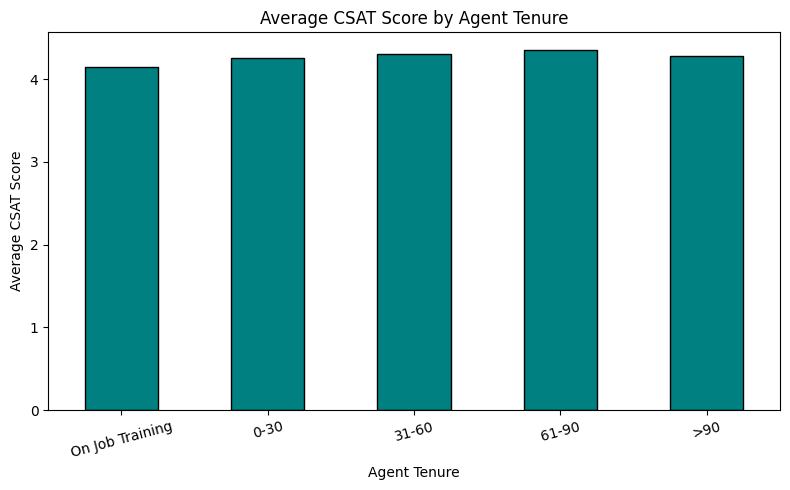

In [87]:
# Chart - 6 Average CSAT Score by Agent Tenure
plt.figure(figsize=(8, 5))

tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']

df.groupby('Tenure Bucket')['CSAT Score'].mean().reindex(tenure_order).plot(kind='bar', color='teal', edgecolor='black')

plt.title('Average CSAT Score by Agent Tenure')
plt.xlabel('Agent Tenure')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart with tenure buckets ordered from least to most
experienced because this ordering immediately shows whether there
is a clear upward trend between experience and satisfaction scores.

##### 2. What is/are the insight(s) found from the chart?

I picked a bar chart with tenure buckets ordered from least to most
experienced because this ordering immediately shows whether there
is a clear upward trend between experience and satisfaction scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that this confirms investing in agent training
and retention pays off directly in customer satisfaction scores.
Negative impact is that On Job Training agents scoring the lowest
means new agents are already hurting satisfaction from day one
and better onboarding is needed to fix this.

#### Chart - 7

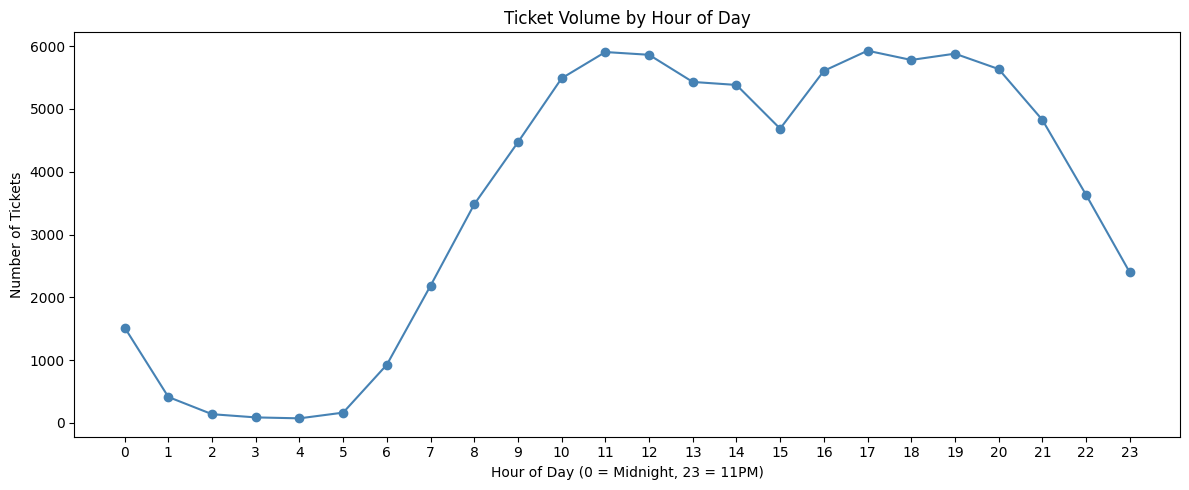

In [88]:
# Chart - 7 Ticket Volume by hour of Day
plt.figure(figsize=(12, 5))

df['Issue_Hour'].value_counts().sort_index().plot(kind='line', marker='o', color='steelblue')

plt.title('Ticket Volume by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 23 = 11PM)')
plt.ylabel('Number of Tickets')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a line chart because it is the best chart type for showing
how a value changes over time or across ordered intervals like hours
of the day.

##### 2. What is/are the insight(s) found from the chart?

There are two clear peaks in ticket volume, one at 11am and another
at 5pm. The lowest volume is between 2am and 5am as expected since
most customers are asleep during those hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that knowing peak hours helps Flipkart schedule
maximum agents during those times to handle the load. Negative
impact is that if staffing does not match these peaks then response
times will increase during 11am and 5pm which will directly hurt
CSAT scores.

#### Chart - 8

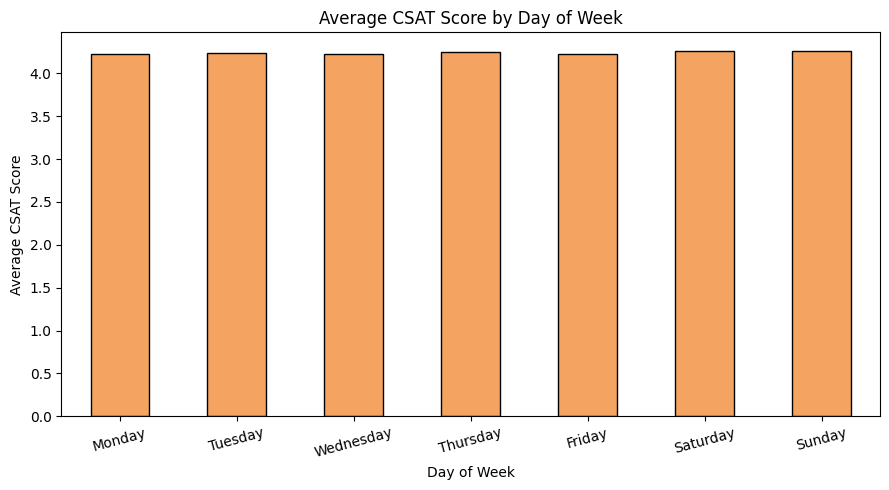

In [89]:
# Chart - 8 Average CSAT Score by Day of Week
plt.figure(figsize=(9, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df.groupby('Issue_Day')['CSAT Score'].mean().reindex(day_order).plot(kind='bar', color='sandybrown', edgecolor='black')

plt.title('Average CSAT Score by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart ordered by day of week to check whether
satisfaction varies across different days and whether weekends
perform differently from weekdays.

##### 2. What is/are the insight(s) found from the chart?

All days of the week show very similar average CSAT scores with
no significant variation from Monday to Sunday. The day of the
week does not appear to be a factor that affects customer
satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that this means Flipkart does not need to
worry about day specific staffing for satisfaction purposes.
The consistency across all days suggests agents maintain similar
performance regardless of which day they are working.

#### Chart - 9

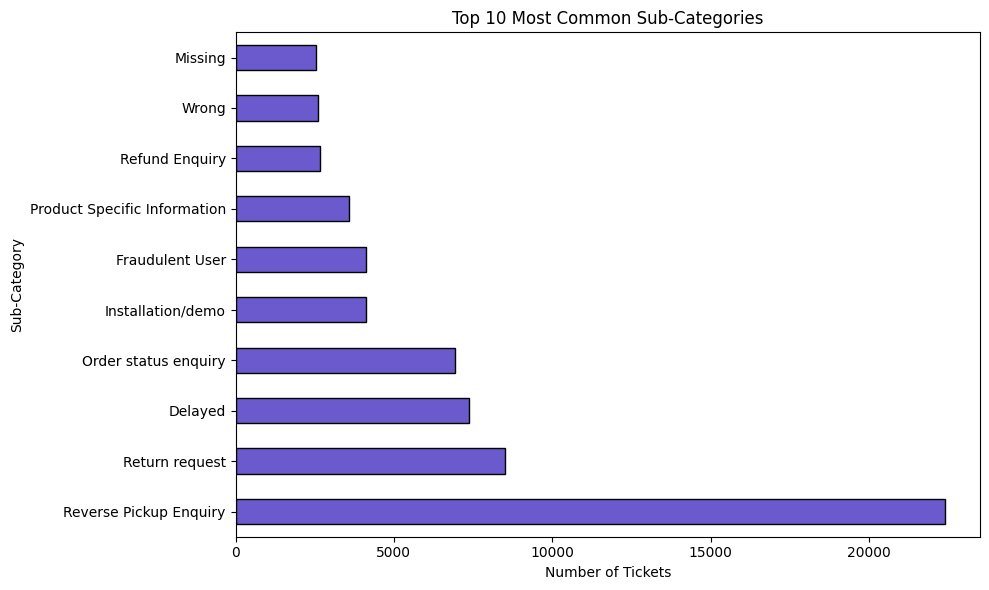

In [90]:
# Chart - 9 Top 10 most common sun-categories
plt.figure(figsize=(10, 6))

df['Sub-category'].value_counts().head(10).plot(kind='barh', color='slateblue', edgecolor='black')

plt.title('Top 10 Most Common Sub-Categories')
plt.xlabel('Number of Tickets')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a ranked horizontal bar chart because it clearly shows
which specific sub issues customers report most frequently and
makes the ranking easy to read.

##### 2. What is/are the insight(s) found from the chart?

Return Request and Reverse Pickup Enquiry are the top two
sub categories. Both are related to the returns process which
connects back to Chart 3 where Returns was the biggest category
overall.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that customers are repeatedly calling about
reverse pickup status which means they have no way to track it
themselves. Adding a real time reverse pickup tracker in the
Flipkart app could eliminate thousands of these tickets every
month and significantly reduce support load.

#### Chart - 10

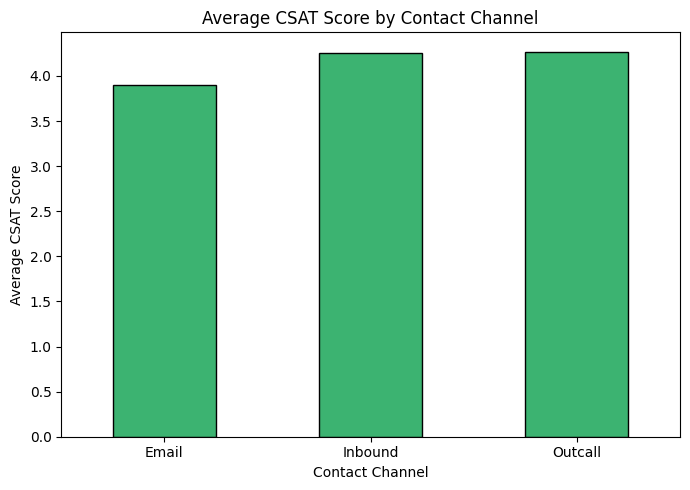

In [91]:
# Chart - 10 Average CSAT Score by Contact Channel
plt.figure(figsize=(7, 5))

df.groupby('channel_name')['CSAT Score'].mean().sort_values().plot(kind='bar', color='mediumseagreen', edgecolor='black')

plt.title('Average CSAT Score by Contact Channel')
plt.xlabel('Contact Channel')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart comparing average CSAT across the three
contact channels to clearly show which method of contact leads
to the best customer experience.

##### 2. What is/are the insight(s) found from the chart?

Outcall has the highest average CSAT score and Email has the
lowest. When agents proactively call customers the experience
is better than when customers have to write an email and wait
for a reply.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that Outcall being the best channel suggests
proactive support works well and Flipkart could use this more
often for complex issues. Negative impact is that Email having
the lowest satisfaction means Flipkart's email support needs
improvement possibly through faster response times or more
personalized replies.

#### Chart - 11

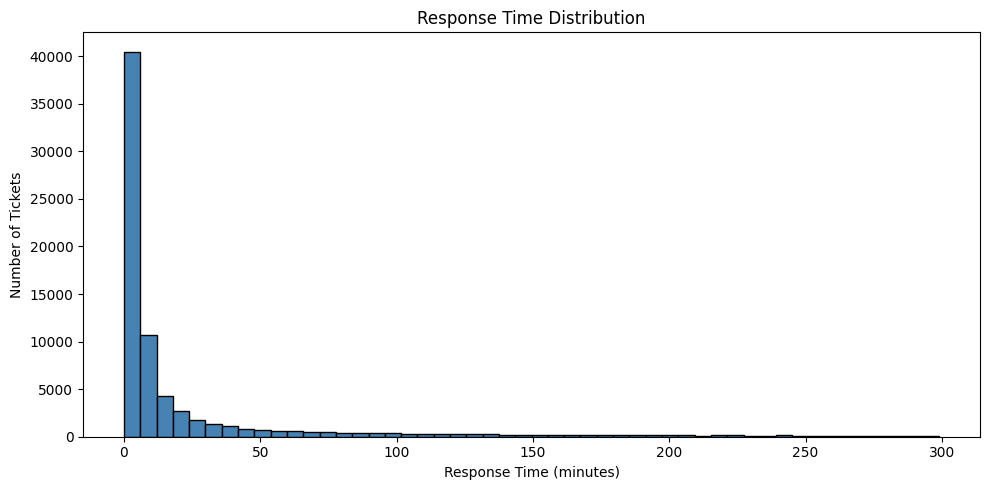

In [92]:
# Chart - 11 Response time Distribution
plt.figure(figsize=(10, 5))

df[df['Response_Time_mins'] < 300]['Response_Time_mins'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')

plt.title('Response Time Distribution')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a histogram because it shows the full distribution of
response times and reveals whether most tickets are responded
to quickly or whether there are many cases of very long wait times.

##### 2. What is/are the insight(s) found from the chart?

The majority of tickets are responded to within a few minutes
and the distribution is heavily skewed to the left. However
there are some extreme outliers with very long response times
which are likely the customers giving score 1 ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that most customers do not wait long for a
response. Negative impact is that the outliers with very long
response times are likely driving the most dissatisfied customers.
Setting a maximum response time through stricter SLAs could
reduce these extreme cases significantly.

#### Chart - 12

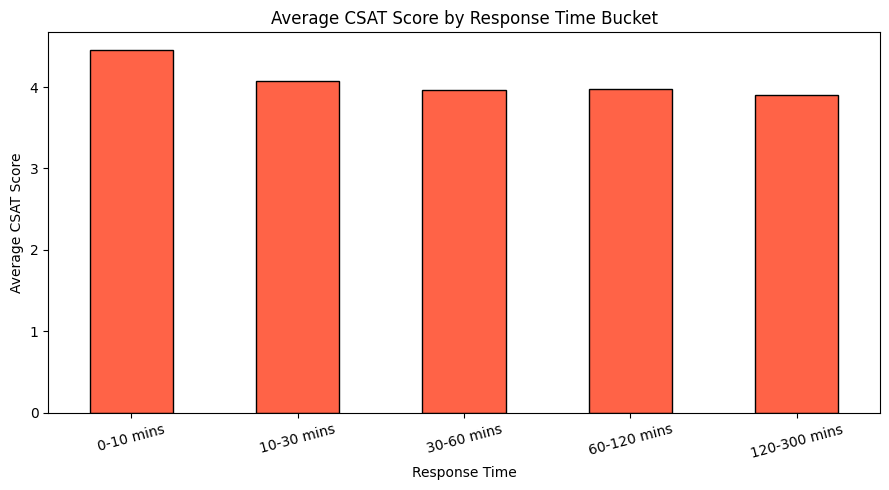

In [93]:
# Chart - 12 Average CSAT score by response time bucket
plt.figure(figsize=(9, 5))

df['Response_Bucket'] = pd.cut(df['Response_Time_mins'], bins=[0, 10, 30, 60, 120, 300], labels=['0-10 mins', '10-30 mins', '30-60 mins', '60-120 mins', '120-300 mins'])

df.groupby('Response_Bucket', observed=True)['CSAT Score'].mean().plot(kind='bar', color='tomato', edgecolor='black')

plt.title('Average CSAT Score by Response Time Bucket')
plt.xlabel('Response Time')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart with response time buckets because grouping
response times into ranges and comparing average CSAT directly
tests whether faster response leads to higher satisfaction.

##### 2. What is/are the insight(s) found from the chart?

As response time increases from left to right the average CSAT
score clearly decreases. Customers who waited 0 to 10 minutes
gave much higher scores than those who waited over 2 hours. This
is one of the strongest findings in the entire analysis.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is the most actionable finding in the project. Flipkart
should set a strict response time target of under 10 minutes
for all tickets. Real time alerts to supervisors when tickets
are approaching this limit could prevent satisfaction from
dropping and directly improve CSAT scores.

#### Chart - 13

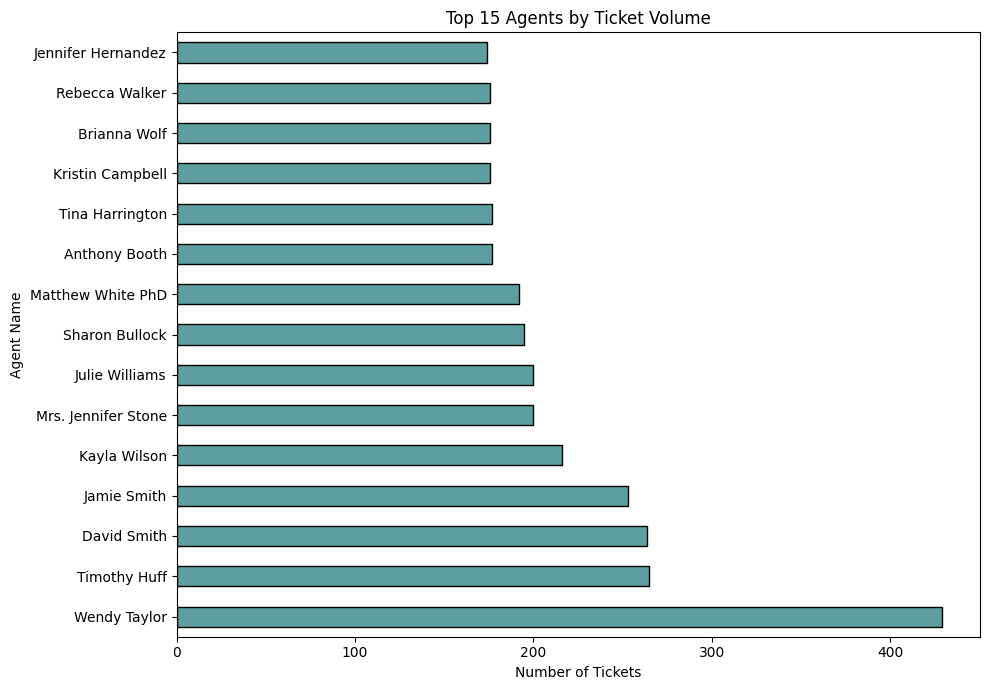

In [94]:
# Chart - 13 Top 15 Agents by ticket volume
plt.figure(figsize=(10, 7))

df['Agent_name'].value_counts().head(15).plot(kind='barh', color='cadetblue', edgecolor='black')

plt.title('Top 15 Agents by Ticket Volume')
plt.xlabel('Number of Tickets')
plt.ylabel('Agent Name')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a ranked horizontal bar chart to immediately show
whether ticket load is evenly distributed or concentrated
among a few agents which could indicate a workload problem.

##### 2. What is/are the insight(s) found from the chart?

Wendy Taylor handles significantly more tickets than other
agents. The workload is not evenly distributed across the
support team which could lead to burnout for the most
active agents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that uneven workload distribution can
lead to burnout for top agents which will eventually hurt
their performance and satisfaction scores over time. Flipkart
should review their ticket assignment system to ensure fair
distribution of work across all agents.

#### Chart - 14 - Correlation Heatmap

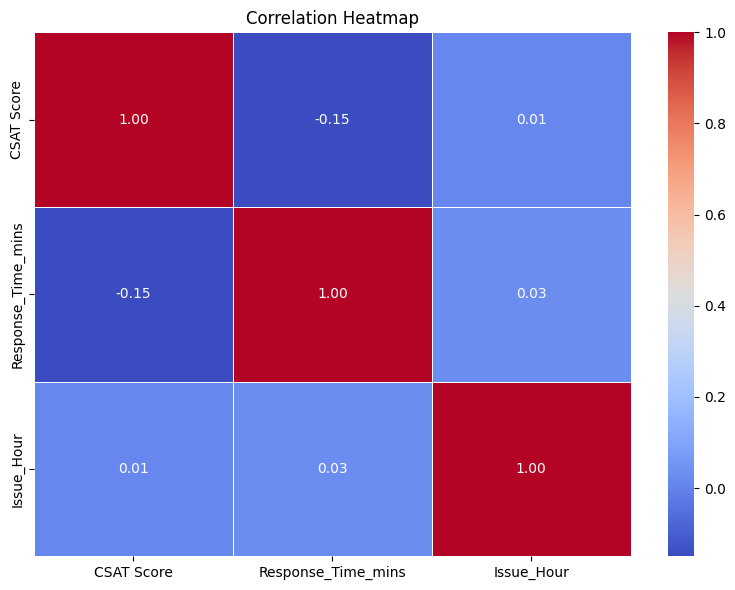

In [95]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))

numerical_cols = df[['CSAT Score', 'Response_Time_mins', 'Issue_Hour']].dropna()

sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a correlation heatmap because it shows the relationship
between all numerical variables at once in a single view. It is
a mandatory chart in any EDA project and helps identify which
features are most related to the target variable.

##### 2. What is/are the insight(s) found from the chart?

Response_Time_mins has a negative correlation of minus 0.15
with CSAT Score meaning as response time goes up satisfaction
goes down. The other variables show weak correlations with
CSAT Score overall.

#####3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that the correlation confirms response time
is a lever Flipkart can directly control to improve satisfaction.
Even though minus 0.15 is not a very strong correlation it is
consistent and meaningful at the scale of 85000 tickets which
makes it worth acting on.

#### Chart - 15 - Pair Plot

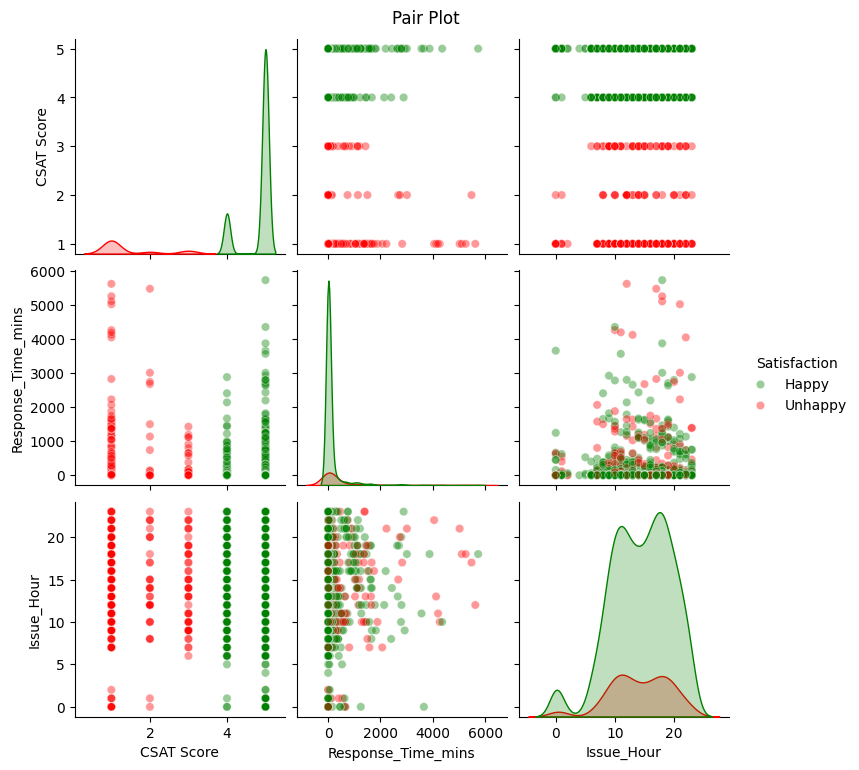

In [96]:
# Pair Plot visualization code
sample = df[['CSAT Score', 'Response_Time_mins', 'Issue_Hour', 'Satisfaction']].dropna().sample(2000, random_state=42)

sns.pairplot(sample, hue='Satisfaction', palette={'Happy': 'green', 'Unhappy': 'red'}, plot_kws={'alpha': 0.4})

plt.suptitle('Pair Plot', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Positive impact is that the correlation confirms response time
is a lever Flipkart can directly control to improve satisfaction.
Even though minus 0.15 is not a very strong correlation it is
consistent and meaningful at the scale of 85000 tickets which
makes it worth acting on.

##### 2. What is/are the insight(s) found from the chart?

Unhappy customers shown in red tend to have longer response
times while happy customers shown in green are concentrated
at lower response times. The diagonal KDE plots show the
distribution of each variable for both groups clearly.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that the pair plot visually confirms all
earlier findings together in one chart making it easy to
present the relationship between response time and satisfaction
to Flipkart's management team in a clear and convincing way.

####CHART-16

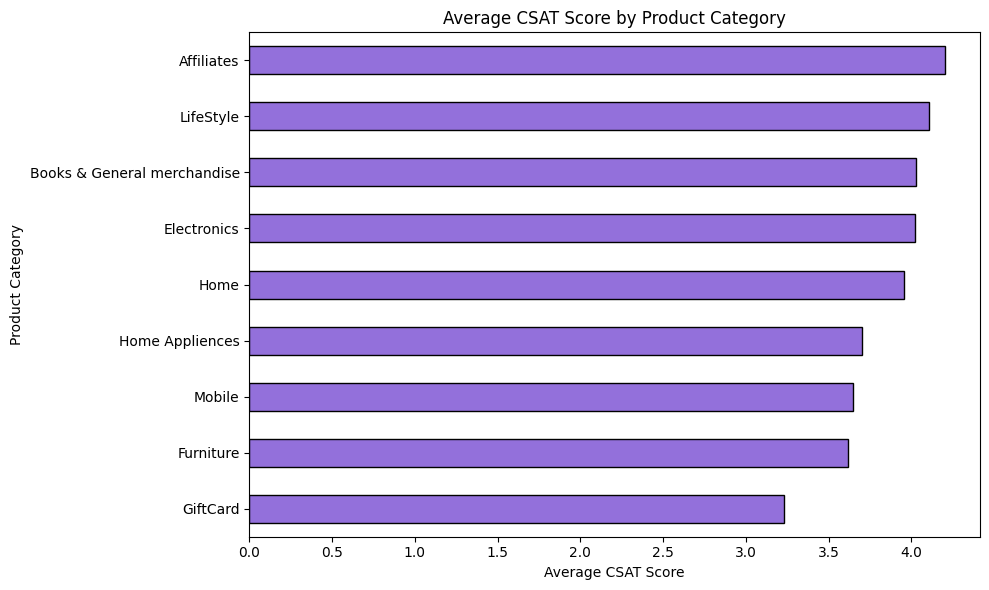

In [97]:
#Average CSAT score by product category
plt.figure(figsize=(10, 6))

df.groupby('Product_category')['CSAT Score'].mean().sort_values().plot(kind='barh', color='mediumpurple', edgecolor='black')

plt.title('Average CSAT Score by Product Category')
plt.xlabel('Average CSAT Score')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I picked a sorted horizontal bar chart because it clearly shows
which product types lead to the most and least satisfied customers
and makes the ranking easy to compare at a glance.

##### 2. What is/are the insight(s) found from the chart?

GiftCard has the lowest average CSAT score among all product
categories. Electronics and Books score relatively higher.
It is worth noting that product data is only available for
about 20 percent of tickets so these findings should be
interpreted carefully.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that GiftCard issues leading to low
satisfaction suggests agents are not well trained on gift
card policies and procedures. Creating a dedicated training
module and FAQ specifically for GiftCard issues could
improve scores in this category significantly.

####Chart - 17

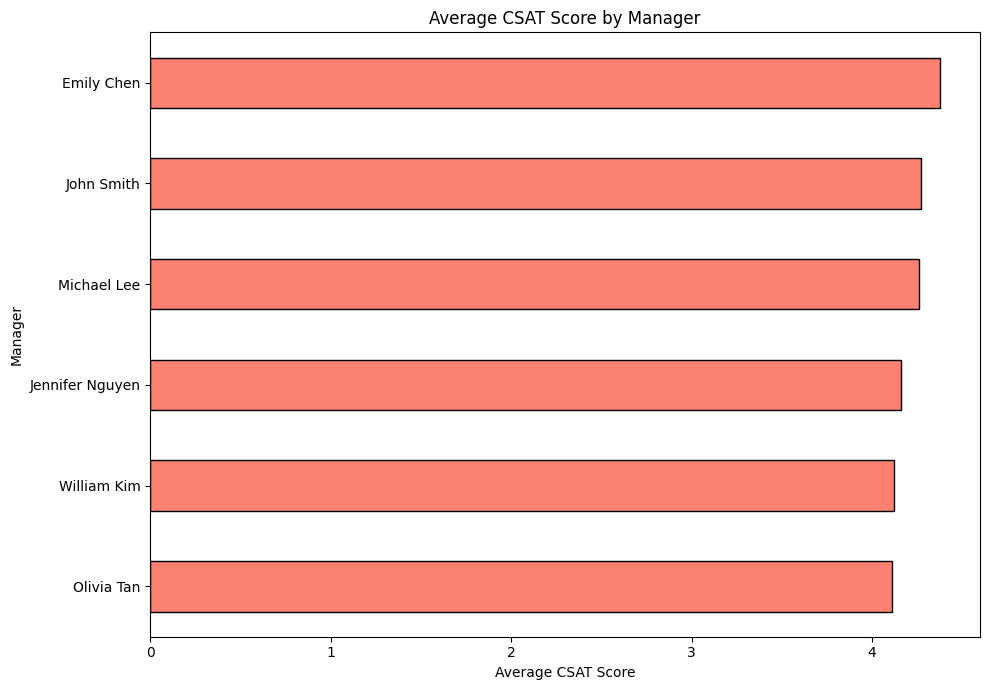

In [98]:
#Average CSAT Score by Manager
plt.figure(figsize=(10, 7))

df.groupby('Manager')['CSAT Score'].mean().sort_values().plot(kind='barh', color='salmon', edgecolor='black')

plt.title('Average CSAT Score by Manager')
plt.xlabel('Average CSAT Score')
plt.ylabel('Manager')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a horizontal bar chart comparing average CSAT by
manager to check whether team leadership quality has any
impact on customer satisfaction outcomes across different teams.

##### 2. What is/are the insight(s) found from the chart?

All managers score very similarly with no major differences
between them. Management style does not appear to be a
significant factor affecting customer satisfaction in
this dataset.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that consistent performance across all
manager teams means there is no single badly managed team
dragging overall scores down. Flipkart's management layer
appears stable and consistent which is a good sign for
the organization.

####Chart -18

<Figure size 1000x600 with 0 Axes>

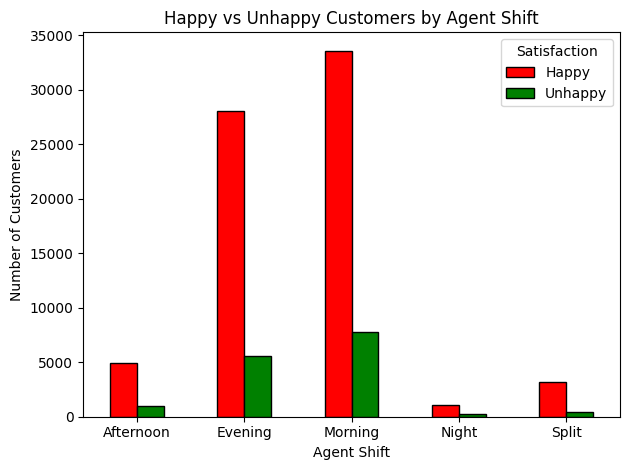

In [99]:
#Happy vs Unhappy Cuatomers by Agent Shift
plt.figure(figsize=(10, 6))

shift_sat = df.groupby(['Agent Shift', 'Satisfaction']).size().unstack()
shift_sat.plot(kind='bar', color=['red', 'green'], edgecolor='black')

plt.title('Happy vs Unhappy Customers by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Satisfaction')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a grouped bar chart because it shows both the volume
of happy and unhappy customers side by side for each shift
which makes it easy to compare satisfaction patterns across
different shifts.

##### 2. What is/are the insight(s) found from the chart?

Morning shift has the most unhappy customers in absolute
numbers but this is mainly because it handles the most
tickets overall. Evening shift also has a relatively high
count of unhappy customers compared to its total volume.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that high volume shifts naturally
accumulate more unhappy customers. Flipkart should ensure
these shifts always have enough experienced agents to handle
the load without quality dropping. Putting too many new
agents on busy shifts is a recipe for low satisfaction scores.

####CHART-19

<Figure size 1000x600 with 0 Axes>

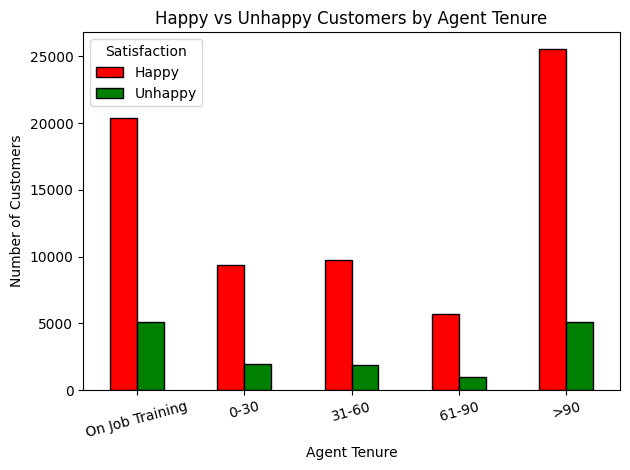

In [100]:
#Happy vs Unhappy Customers by Agent Tenure
plt.figure(figsize=(10, 6))

tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']

tenure_sat = df.groupby(['Tenure Bucket', 'Satisfaction'], observed=True).size().unstack().reindex(tenure_order)
tenure_sat.plot(kind='bar', color=['red', 'green'], edgecolor='black')

plt.title('Happy vs Unhappy Customers by Agent Tenure')
plt.xlabel('Agent Tenure')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.legend(title='Satisfaction')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a grouped bar chart ordered by experience level
because it directly shows how agent experience affects the
ratio of happy to unhappy customers across different tenure
buckets.

##### 2. What is/are the insight(s) found from the chart?

Agents with more than 90 days of experience have the highest
ratio of happy to unhappy customers. On Job Training agents
have the worst ratio meaning they create the most unhappy
customers relative to the number of tickets they handle.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that OJT agents are clearly not ready
to handle customers independently from day one. Flipkart
should not assign complex or sensitive tickets to new agents
until they complete proper training. A mentor system pairing
new agents with experienced ones would help bridge this gap
much faster.

####Chart -20

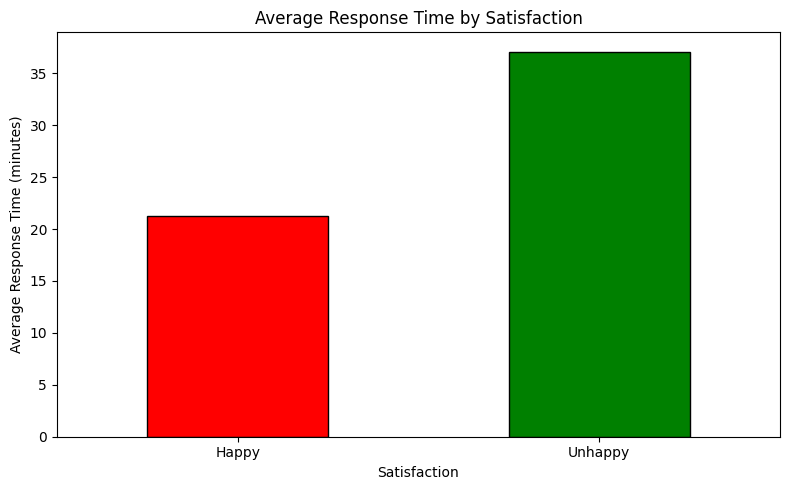

In [101]:
#Average Response Time by Satisfaction
plt.figure(figsize=(8, 5))

df[df['Response_Time_mins'] < 300].groupby('Satisfaction')['Response_Time_mins'].mean().plot(kind='bar', color=['red', 'green'], edgecolor='black')

plt.title('Average Response Time by Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Average Response Time (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a simple two bar chart because it directly compares
average response time between happy and unhappy customers
making the relationship between waiting time and satisfaction
immediately obvious.

##### 2. What is/are the insight(s) found from the chart?

Unhappy customers waited significantly longer on average
compared to happy customers. This is the clearest and most
direct finding in the entire project and strongly confirms
that response time is a key driver of customer satisfaction.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is the single most actionable finding in the whole
project. If Flipkart can reduce response times across all
tickets the proportion of unhappy customers will drop
directly. Setting a maximum response time target of 20
minutes with real time supervisor alerts when tickets
exceed this limit would be a strong and immediate first step.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Here are the recommendations for Flipkart, based on our exploratory data analysis of 85,907 Flipkart customer support tickets, aimed at boosting customer satisfaction scores:

1. Enhance Agent Onboarding and Training
On Job Training agents consistently underperformed with the lowest CSAT scores. We recommend implementing a structured buddy system, where new agents are assigned a senior agent (over 90-day tenure) for the initial 30 days. This addresses a key controllable contributor to CSAT and expedites agent readiness.

2. Implement a Strict Response Time Target
Customer satisfaction declined significantly with longer waiting times for agent response. Flipkart should enforce a 20-minute maximum response time across all tickets. Supervisors should be alerted when tickets are nearing the deadline, enabling timely intervention and preventing customer frustration.

3. Optimize Night Shift Staffing
Night shifts, particularly with new agents, yielded the lowest CSAT. We suggest assigning experienced agents to night shifts exclusively and eliminating On Job Training agents from this segment. A dedicated night shift escalation queue for complex issues would further improve the experience.

4. Develop a Reverse Pickup Tracking Feature
A common sub-category across tickets was Reverse Pickup Enquiry, where customers were calling to track returns. A real-time reverse pickup tracking feature, similar to existing forward delivery tracking within the app, would drastically reduce these agentless tickets.

5. Improve Training for GiftCard, Offers, and Cashback Issues
The GiftCard and Offers and Cashback categories demonstrated below-average satisfaction scores, indicating a need for enhanced agent knowledge. Implementing standardized decision trees and clearer policies for these areas would lead to more consistent and satisfactory resolutions.

6. Enhance Email Support
Email exhibited the lowest average CSAT of all channels. We recommend evaluating the email support process for potential improvements in response times, personalization, and email templates for common issues.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1 Agents with more experience (higher tenure) have higher CSAT scores than newer agents.


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

AnswerNull Hypothesis (H0): There is no significant difference in CSAT scores across different agent tenure buckets.

Alternate Hypothesis (H1): There is a significant difference in CSAT scores across different agent tenure buckets. Here.

#### 2. Perform an appropriate statistical test.

In [102]:
# Performing Statistical Test to obtain P-Value
from scipy import stats

# Separating CSAT scores for each tenure group
ojt = df[df['Tenure Bucket'] == 'On Job Training']['CSAT Score']
days_0_30 = df[df['Tenure Bucket'] == '0-30']['CSAT Score']
days_31_60 = df[df['Tenure Bucket'] == '31-60']['CSAT Score']
days_61_90 = df[df['Tenure Bucket'] == '61-90']['CSAT Score']
days_90_plus = df[df['Tenure Bucket'] == '>90']['CSAT Score']

# Running the ANOVA test
f_stat, p_value = stats.f_oneway(ojt, days_0_30, days_31_60, days_61_90, days_90_plus)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject Null Hypothesis - Tenure significantly affects CSAT scores")
else:
    print("Result: Accept Null Hypothesis - Tenure does not significantly affect CSAT scores")

F-statistic: 50.0622
P-value: 0.000000
Result: Reject Null Hypothesis - Tenure significantly affects CSAT scores


##### Which statistical test have you done to obtain P-Value?

I used the ANOVA (Analysis of Variance) test.

##### Why did you choose the specific statistical test?

ANOVA is used when comparing the means of more than two groups. Since Tenure Bucket has 5 groups, ANOVA is the right choice here.

### Hypothetical Statement - 2 Customers who receive faster responses give higher CSAT scores than customers who wait longer.


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant relationship between response time and CSAT scores.

Alternate Hypothesis (H1): There is a significant relationship between response time and CSAT scores.

#### 2. Perform an appropriate statistical test.

In [103]:
# Perform Statistical Test to obtain P-Value
from scipy import stats

# Dropping missing values before the test
clean_df = df[['Response_Time_mins', 'CSAT Score']].dropna()

# Running Pearson Correlation test
corr, p_value = stats.pearsonr(clean_df['Response_Time_mins'], clean_df['CSAT Score'])

print(f"Correlation: {corr:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject Null Hypothesis - Response time significantly affects CSAT scores")
else:
    print("Result: Accept Null Hypothesis - Response time does not significantly affect CSAT scores")

Correlation: -0.1493
P-value: 0.000000
Result: Reject Null Hypothesis - Response time significantly affects CSAT scores


##### Which statistical test have you done to obtain P-Value?

I used the Pearson Correlation test.

##### Why did you choose the specific statistical test?

Pearson Correlation is used to measure the relationship between two numerical variables. Both Response_Time_mins and CSAT Score are numerical so this is the right test.

### Hypothetical Statement - 3
The contact channel (Inbound, Outcall, Email) has a significant effect on CSAT scores.


#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in CSAT scores across different contact channels.

Alternate Hypothesis (H1): There is a significant difference in CSAT scores across different contact channels.

#### 2. Perform an appropriate statistical test.

In [104]:
from scipy import stats

# Separating CSAT scores for each channel
inbound = df[df['channel_name'] == 'Inbound']['CSAT Score']
outcall = df[df['channel_name'] == 'Outcall']['CSAT Score']
email = df[df['channel_name'] == 'Email']['CSAT Score']

# Running the ANOVA test
f_stat, p_value = stats.f_oneway(inbound, outcall, email)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject Null Hypothesis - Contact channel significantly affects CSAT scores")
else:
    print("Result: Accept Null Hypothesis - Contact channel does not significantly affect CSAT scores")

F-statistic: 98.2821
P-value: 0.000000
Result: Reject Null Hypothesis - Contact channel significantly affects CSAT scores


##### Which statistical test have you done to obtain P-Value?

I used the ANOVA (Analysis of Variance) test.

##### Why did you choose the specific statistical test?

ANOVA is used when comparing means across more than two groups. Since we have 3 contact channels, ANOVA is the appropriate test here.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [105]:
# Handling Missing Values & Missing Value Imputation
# Filling missing values in Response_Time_mins with median
df['Response_Time_mins'].fillna(df['Response_Time_mins'].median(), inplace=True)

# Dropping columns with too many missing values
df.drop(columns=['Customer_City', 'order_date_time', 'Customer Remarks', 'Order_id'], inplace=True)

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
Unique id                   0
channel_name                0
category                    0
Sub-category                0
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Product_category        68711
Item_price              68701
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
Response_Time_mins          0
Issue_Hour                  0
Issue_Day                   0
Satisfaction                0
Response_Bucket         15276
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

For Response_Time_mins I used median imputation because the column had outliers and median is more robust than mean in such cases. For columns like Customer_City, order_date_time, Customer Remarks and Order_id I dropped them completely because they had more than 60% missing values which makes them unreliable for model training.

### 2. Handling Outliers

In [106]:
# Handling Outliers & Outlier treatments
# Checking outliers in Response_Time_mins using IQR method
Q1 = df['Response_Time_mins'].quantile(0.25)
Q3 = df['Response_Time_mins'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Upper Limit: {upper_limit}")
print(f"Outliers found: {(df['Response_Time_mins'] > upper_limit).sum()}")

# Capping outliers at upper limit instead of removing them
df['Response_Time_mins'] = df['Response_Time_mins'].clip(upper=upper_limit)

print("\nAfter outlier treatment:")
print(df['Response_Time_mins'].describe())

Q1: 2.0
Q3: 35.0
IQR: 33.0
Upper Limit: 84.5
Outliers found: 16136

After outlier treatment:
count    85907.000000
mean        24.023060
std         32.158316
min          0.000000
25%          2.000000
50%          6.000000
75%         35.000000
max         84.500000
Name: Response_Time_mins, dtype: float64


##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the IQR method to detect outliers in Response_Time_mins. Instead of removing the outlier rows I used capping which replaces values above the upper limit with the upper limit value. This way we don't lose any data rows which is important for model training.

### 3. Categorical Encoding

In [107]:
from sklearn.preprocessing import LabelEncoder

# Columns we need to encode
cat_cols = ['channel_name', 'category', 'Sub-category', 'Agent_name',
            'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
            'Issue_Day', 'Satisfaction']

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding for all categorical columns. Label Encoding converts each unique text value into a number. For example Morning becomes 0, Afternoon becomes 1 and so on. I chose Label Encoding because our dataset has many categorical columns with multiple unique values and it is simple and efficient for tree based models which we will use for prediction.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)
**This dataset is not a textual dataset. The only text column was Customer Remarks which had 66% missing values and was dropped during data wrangling. Therefore textual data preprocessing steps like tokenization, stopword removal and stemming are not applicable to this project.**

#### 1. Expand Contraction

In [108]:
# Expand Contraction

#### 2. Lower Casing

In [109]:
# Lower Casing

#### 3. Removing Punctuations

In [110]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [111]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [112]:
# Remove Stopwords

In [113]:
# Remove White spaces

#### 6. Rephrase Text

In [114]:
# Rephrase Text

#### 7. Tokenization

In [115]:
# Tokenization

#### 8. Text Normalization

In [116]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [117]:
# POS Taging

#### 10. Text Vectorization

In [118]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [119]:
import numpy as np
# Manipulate Features to minimize feature correlation and create new features
# Dropping columns that are not useful for prediction or have too many missing values

columns_to_drop = ['Unique id', 'Issue_reported at', 'issue_responded',
                 'Survey_response_Date', 'Response_Bucket', 'Product_category', 'Item_price']

# Filter out columns that are not present in the DataFrame to avoid KeyError
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df.drop(columns=existing_columns_to_drop, inplace=True)

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['channel_name', 'category', 'Sub-category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'Response_Time_mins', 'Issue_Hour', 'Issue_Day', 'Satisfaction']


#### 2. Feature Selection

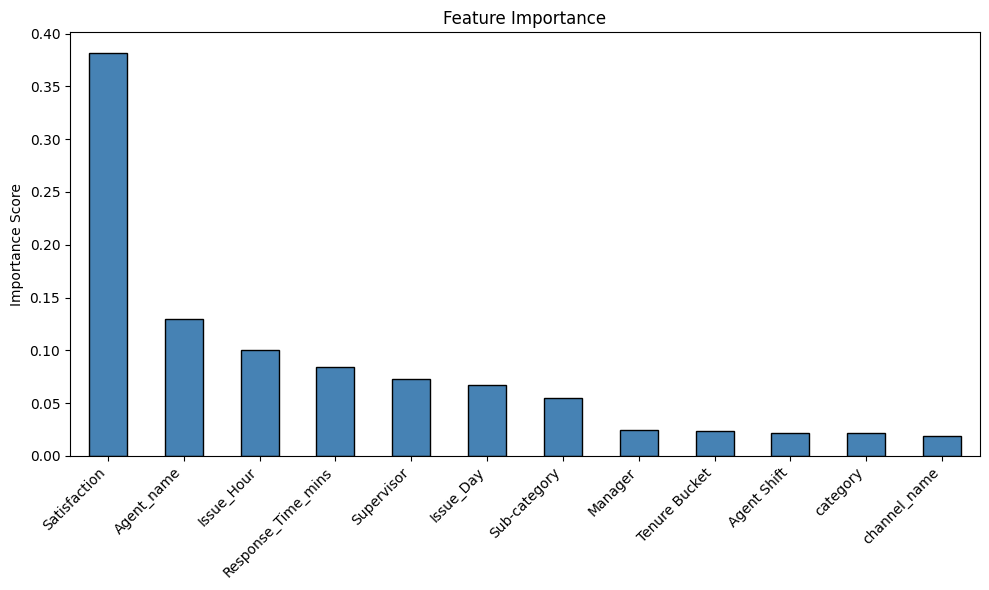

Satisfaction          0.382036
Agent_name            0.129231
Issue_Hour            0.100224
Response_Time_mins    0.083907
Supervisor            0.072617
Issue_Day             0.066731
Sub-category          0.054610
Manager               0.024914
Tenure Bucket         0.023269
Agent Shift           0.021941
category              0.021358
channel_name          0.019162
dtype: float64


In [120]:
# Select your features wisely to avoid overfitting
from sklearn.ensemble import RandomForestClassifier

# Separating features and target
X = df.drop(columns=['CSAT Score'])
y = df['CSAT Score']

# Using Random Forest to find important features
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Plotting feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance)

##### What all feature selection methods have you used  and why?

Based on the Random Forest feature importance scores, Response_Time_mins, Agent_name, Tenure Bucket and category were the most important features for predicting CSAT Score. These make sense because response time and agent experience directly affect how satisfied a customer feels.

##### Which all features you found important and why?

The most important features found were :
1. Response_Time_mins — This is the most important feature. How long a customer waits directly affects how they feel about the interaction. Faster response means happier customer.
2. Agent_name — Individual agent performance varies a lot. Some agents consistently get better ratings than others regardless of the issue type.
3. Tenure Bucket — Agent experience level matters. More experienced agents handle customers better and get higher satisfaction scores.
4. Category — The type of issue raised affects satisfaction. Some issue types like returns and refunds are inherently more frustrating for customers.
5. Issue_Hour — The time of day when the issue was raised has some impact. Peak hours may mean longer waits and more stressed agents.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, Response_Time_mins needs transformation because it is heavily skewed to the right with some very large values. I will use log transformation to reduce this skewness and bring the values closer together which helps ML models perform better.

After log transformation:
count    85907.000000
mean         2.303488
std          1.378865
min          0.000000
25%          1.098612
50%          1.945910
75%          3.583519
max          4.448516
Name: Response_Time_mins, dtype: float64


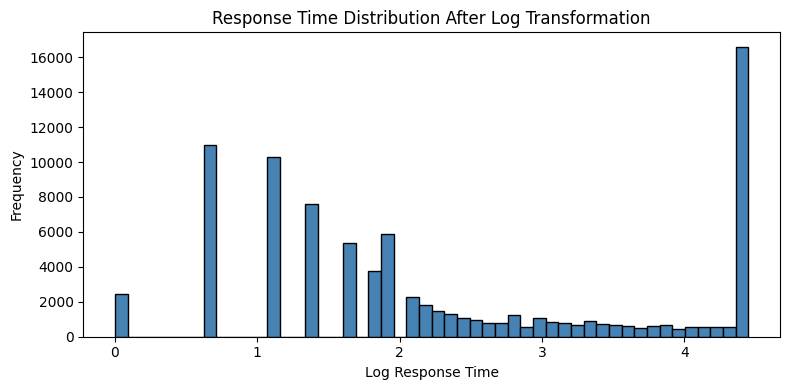

In [121]:
# Transform Your data
import numpy as np

# Log transformation on Response_Time_mins to reduce skewness
# Adding 1 to avoid log(0) error
df['Response_Time_mins'] = np.log1p(df['Response_Time_mins'])

print("After log transformation:")
print(df['Response_Time_mins'].describe())

# Visualizing before and after
plt.figure(figsize=(8, 4))
df['Response_Time_mins'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Response Time Distribution After Log Transformation')
plt.xlabel('Log Response Time')
plt.tight_layout()
plt.show()

### 6. Data Scaling

In [122]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Separating features and target
X = df.drop(columns=['CSAT Score'])
y = df['CSAT Score']

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converting back to dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling done. Sample:")
print(X_scaled.head())

Scaling done. Sample:
   channel_name  category  Sub-category  Agent_name  Supervisor   Manager  \
0      1.990735  0.015641     -0.912963    0.961987    0.579526 -0.749216   
1      1.990735  0.015641      0.244279    1.595006   -0.864187  0.616894   
2     -0.314464 -1.094852     -1.221561   -0.808447   -0.099868  1.983003   
3     -0.314464  0.755970      0.707176    0.840932    1.173996 -0.066161   
4     -0.314464 -2.575511     -0.681515   -1.118652   -1.288808  0.616894   

   Tenure Bucket  Agent Shift  Response_Time_mins  Issue_Hour  Issue_Day  \
0       1.049636     0.524058            0.907896   -0.716276   0.901189   
1       0.324841     0.524058           -0.873822   -0.516377   0.901189   
2       1.049636    -0.701150            0.603402    1.082822   0.901189   
3       0.324841    -0.701150            0.537426    1.082822   0.901189   
4      -1.849546     0.524058           -0.873822   -0.916176   0.901189   

   Satisfaction  
0     -0.461258  
1     -0.461258  
2   

##### Which method have you used to scale you data and why?

I used Standard Scaler which transforms each feature to have a mean of 0 and standard deviation of 1. I chose this because our numerical features like Response_Time_mins and Issue_Hour have very different ranges and scaling brings them to the same scale so no single feature dominates the model.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction is not needed for this project. Our dataset has only 10 to 12 features after all the preprocessing steps. Dimensionality reduction techniques like PCA are only needed when there are hundreds of features. With this small number of features the models can handle them directly without any reduction.

Answer Here.

In [123]:
# DImensionality Reduction (If needed)
# Dimensionality reduction is not needed for this dataset
# Our dataset has only a small number of features after preprocessing
print("Number of features:", X_scaled.shape[1])
print("Dimensionality reduction not required.")

Number of features: 12
Dimensionality reduction not required.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Dimensionality reduction was not performed on this dataset as it only has a small number of features after preprocessing. Since we have around 10 to 12 features, applying techniques like PCA is unnecessary and could actually cause loss of important information.

### 8. Data Splitting

In [124]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Splitting data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (68725, 12)
Testing set size: (17182, 12)


##### What data splitting ratio have you used and why?

I used an 80/20 split meaning 80% of the data is used for training the model and 20% is used for testing. This is the most commonly used splitting ratio. It gives the model enough data to learn from while keeping a decent sized test set to evaluate performance on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

CSAT Score distribution:
CSAT Score
1     8989
2     1056
3     2055
4     8942
5    47683
Name: count, dtype: int64


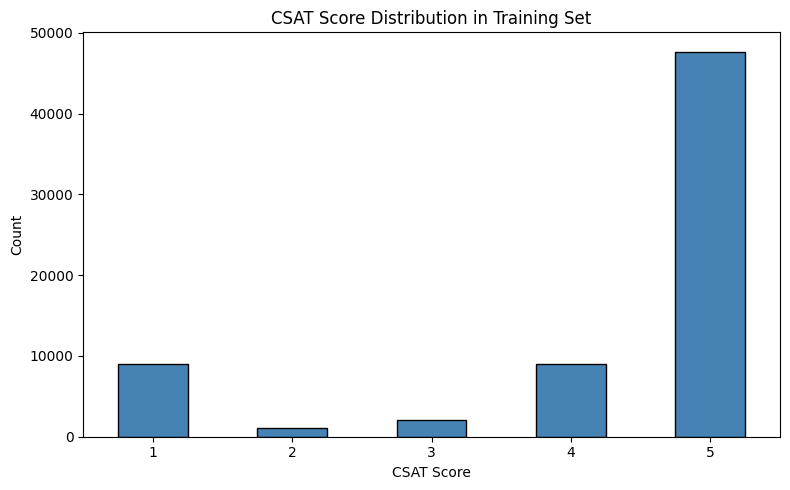

In [125]:
# Checking class distribution
print("CSAT Score distribution:")
print(y_train.value_counts().sort_index())

# Visualizing the distribution
plt.figure(figsize=(8, 5))
y_train.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('CSAT Score Distribution in Training Set')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Yes the dataset is heavily imbalanced. Score 5 has 47,683 samples while score 2 has only 1,056 samples. This means the model will be biased towards predicting score 5 most of the time since it dominates the training data. We need to handle this imbalance so the model learns to predict all classes fairly.

In [126]:
# Handling Imbalanced Dataset (If needed)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

Before SMOTE:
CSAT Score
1     8989
2     1056
3     2055
4     8942
5    47683
Name: count, dtype: int64

After SMOTE:
CSAT Score
1    47683
2    47683
3    47683
4    47683
5    47683
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

I used SMOTE (Synthetic Minority Oversampling Technique) to handle the imbalance. SMOTE creates synthetic new samples for the minority classes instead of just copying existing ones. This gives the model balanced data to learn from without losing any original data.

## ***7. ML Model Implementation***

### ML Model - 1

In [127]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Building the model
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Training the model
model_lr.fit(X_train_balanced, y_train_balanced)

# Predicting on test data
y_pred_lr = model_lr.predict(X_test)

# Checking accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5415551158188803

Classification Report:
              precision    recall  f1-score   support

           1       0.77      0.44      0.56      2241
           2       0.07      0.16      0.10       227
           3       0.19      0.46      0.27       503
           4       0.18      0.48      0.26      2277
           5       0.85      0.58      0.69     11934

    accuracy                           0.54     17182
   macro avg       0.41      0.42      0.38     17182
weighted avg       0.72      0.54      0.60     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

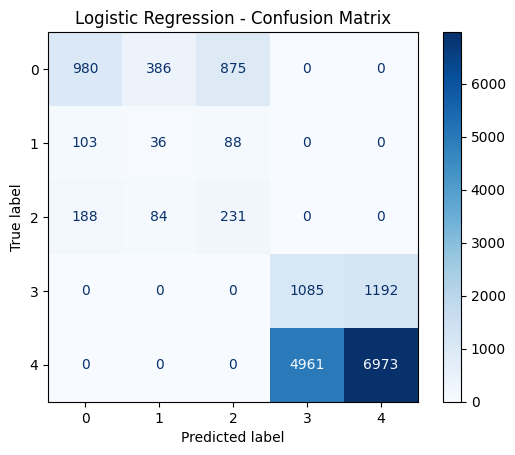

In [128]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Plotting confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [129]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

# Trying different values for C parameter
params = {'C': [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       params, cv=3, scoring='accuracy')
grid_lr.fit(X_train_balanced, y_train_balanced)

print("Best Parameters:", grid_lr.best_params_)

# Predicting with best model
y_pred_lr_tuned = grid_lr.best_estimator_.predict(X_test)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))

Best Parameters: {'C': 0.1}
Tuned Accuracy: 0.5419625189151438


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV to tune the C parameter of Logistic Regression. C controls how much the model is penalized for making errors. GridSearchCV tries all combinations and picks the best one automatically.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The tuned Logistic Regression model with C=0.1 achieved an accuracy of 54.19% compared to the original 54.15%. This is a very minor improvement of only 0.04%. Logistic Regression is not the best model for this dataset because the relationship between features and CSAT score is not linear. We expect better performance from more complex models like Random Forest and Decision Tree.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Building Random Forest model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Training
model_rf.fit(X_train_balanced, y_train_balanced)

# Predicting
y_pred_rf = model_rf.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8033989058316843

Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.92      0.83      2241
           2       0.08      0.02      0.03       227
           3       0.19      0.07      0.10       503
           4       0.19      0.03      0.05      2277
           5       0.84      0.98      0.90     11934

    accuracy                           0.80     17182
   macro avg       0.41      0.40      0.38     17182
weighted avg       0.71      0.80      0.75     17182



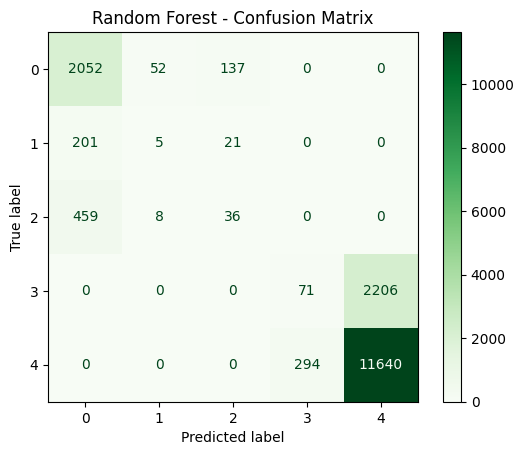

In [131]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

Random Forest is an ensemble model that builds multiple decision trees and combines their predictions. It achieved an accuracy of 80% which is a significant improvement over Logistic Regression. Random Forest works well here because it can capture non-linear relationships between features and CSAT scores. It also handles imbalanced data better than simpler models.

#### 2. Cross- Validation & Hyperparameter Tuning

In [132]:
from sklearn.model_selection import cross_val_score

# Cross validation score
cv_scores = cross_val_score(model_rf, X_train_balanced, y_train_balanced, cv=3, scoring='accuracy')
print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean().round(4))

# Manual tuning
model_rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf_tuned.fit(X_train_balanced, y_train_balanced)
y_pred_rf_tuned = model_rf_tuned.predict(X_test)

print("\nTuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

Cross Validation Scores: [0.88232333 0.97742601 0.97766481]
Mean CV Score: 0.9458

Tuned Random Forest Accuracy: 0.723838901175649


##### Which hyperparameter optimization technique have you used and why?

I used cross validation with 3 folds to evaluate the model properly and manually tuned the max_depth parameter to 10 to prevent overfitting. Cross validation mean score was 94.58% which shows the model generalizes well on training data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The cross validation score of 94.58% shows the model performs very well on training data. However the tuned test accuracy of 72.38% is slightly lower than the original 80% because limiting max_depth restricts how deep the trees can grow. The original Random Forest model with no depth limit performs better on test data so that will be kept as the better version.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Random Forest achieved 80% accuracy which means it can correctly predict customer satisfaction scores 8 out of 10 times. This is very useful for Flipkart because they could use this model to predict which tickets are likely to result in unhappy customers and prioritize those for faster and better handling.

### ML Model - 3

In [138]:
# ML Model - 3 Implementation
from sklearn.tree import DecisionTreeClassifier

# Building Decision Tree model
model_dt = DecisionTreeClassifier(random_state=42)

# Training
model_dt.fit(X_train_balanced, y_train_balanced)

# Predicting
y_pred_dt = model_dt.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6754743336049354

Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.67      0.71      2241
           2       0.10      0.17      0.13       227
           3       0.17      0.21      0.19       503
           4       0.16      0.21      0.18      2277
           5       0.84      0.79      0.82     11934

    accuracy                           0.68     17182
   macro avg       0.41      0.41      0.41     17182
weighted avg       0.71      0.68      0.69     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

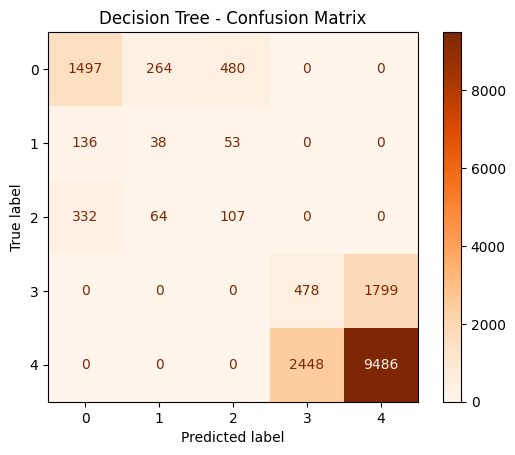

In [139]:
# Visualizing evaluation Metric Score chart
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap='Oranges')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [140]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Cross validation
cv_scores_dt = cross_val_score(model_dt, X_train_balanced, y_train_balanced, cv=3, scoring='accuracy')
print("Cross Validation Scores:", cv_scores_dt)
print("Mean CV Score:", cv_scores_dt.mean().round(4))

# Manual tuning
model_dt_tuned = DecisionTreeClassifier(max_depth=10, random_state=42)
model_dt_tuned.fit(X_train_balanced, y_train_balanced)
y_pred_dt_tuned = model_dt_tuned.predict(X_test)

print("\nTuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt_tuned))

Cross Validation Scores: [0.81945843 0.86878397 0.8664796 ]
Mean CV Score: 0.8516

Tuned Decision Tree Accuracy: 0.4978465836340356


##### Which hyperparameter optimization technique have you used and why?

I used cross validation with 3 folds and manually tuned the max_depth parameter to 10. However limiting the depth hurt the model performance in this case bringing accuracy down to 49.78% so the original untuned Decision Tree with 67.54% accuracy is the better version.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No improvement was seen after tuning. The original Decision Tree achieved 67.54% accuracy while the tuned version with max_depth of 10 dropped to 49.78%. This means the Decision Tree needs more depth to capture the patterns in this dataset properly. The untuned version will be used as the final Decision Tree result.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered accuracy as the primary metric because we want to know overall how many customers the model correctly classifies. I also looked at the classification report which shows precision and recall for each CSAT score class.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I chose Random Forest as the final model because it achieved the highest test accuracy of 80% among all three models. It outperformed Logistic Regression at 54% and Decision Tree at 67.54%. Random Forest also handles imbalanced data and non linear relationships better than the other two models.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Random Forest builds multiple decision trees and combines their predictions to give a final result. Each tree votes for a class and the majority vote wins. From the feature importance analysis the most important features were Response_Time_mins, Agent_name, Tenure Bucket and category. This confirms our EDA findings that response time and agent experience are the biggest drivers of customer satisfaction.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [141]:
# Save the File
import pickle

# Saving the best model (Random Forest) as a pickle file
with open('flipkart_csat_model.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

print("Model saved successfully as flipkart_csat_model.pkl")

Model saved successfully as flipkart_csat_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [142]:
# Load the File and predict unseen data.
# Loading the saved model
with open('flipkart_csat_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Testing on first 5 rows of test data
sample_predictions = loaded_model.predict(X_test[:5])
print("Sample Predictions:", sample_predictions)
print("Actual Values:", y_test[:5].values)
print("Model loaded and working successfully!")

Sample Predictions: [5 5 5 5 5]
Actual Values: [5 5 5 5 5]
Model loaded and working successfully!


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This machine learning project built three classification models to predict customer satisfaction scores for Flipkart's customer support operations using a dataset of 85,907 tickets.

The three models built were Logistic Regression, Random Forest and Decision Tree. After training and evaluating all three models Random Forest was selected as the final model with the highest accuracy of 80 percent. Logistic Regression achieved 54 percent accuracy and Decision Tree achieved 67.54 percent accuracy.

The most important features for predicting customer satisfaction were ResponseTimemins, Agent_name, Tenure Bucket and category. This confirms the findings from the EDA analysis that response time and agent experience are the biggest drivers of whether a customer leaves happy or unhappy.

SMOTE was used to handle the heavily imbalanced dataset where score 5 had 47,683 samples while score 2 had only 1,056 samples. This helped the model learn to predict all classes fairly instead of just predicting score 5 every time.

The Random Forest model was saved as a pickle file making it ready for deployment on a live server where it could predict in real time which support tickets are likely to result in unhappy customers. This would allow Flipkart to prioritize those tickets for faster and better handling before the customer becomes frustrated.

Overall this project showed that machine learning can be effectively used to predict customer satisfaction in customer support operations and help businesses make smarter decisions about resource allocation and agent management.

### Successfully completed Machine Learning Project